In [2]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import InputLayer, Dense
from tensorflow.keras import Sequential
from tensorflow.keras.backend import clear_session
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [4]:
bc = load_breast_cancer()
X = bc.data
y= bc.target

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

In [6]:
def get_model():
    model = Sequential()
    model.add(Dense(units=16, activation='relu', input_dim =30))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(
        optimizer = 'adam',
        loss = 'binary_crossentropy',
        metrics = ["accuracy"]
    )
    return model

In [7]:
class PerBatchLossLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        print("PerBatchLossLogger Initialized")

    # Init loss logs
    def on_train_begin(self, *arg, **kwargs):
        self.batch_loss = []

    def on_train_batch_end(self, batch, logs):
        print(f"Batch: {batch}\nLoss: {logs['loss']}\n")
        # Save loss
        self.batch_loss.append(logs["loss"])
        return

In [8]:
class PerEpochLRSetterCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        print("PerEpochLRSetter Initialized")
    
    def on_epoch_begin(self, epoch, arg, **kargs):
        newLR = 0.001 if epoch % 2 == 0 else 0.005
        self.model.optimizer.learning_rate = newLR
        print(f"Epoch {epoch} starting with LR: {newLR}")
        return
    

In [9]:
class EarlyStopperCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        print("EarlyStopper Initialized")

    def on_epoch_end(self, epoch, logs = None):
        accuracy = logs.get("accuracy")
        treshold = 0.9

        if accuracy is not None and accuracy >= treshold:
            print(f"Stopping Early: epoch {epoch}, accuracy = {accuracy}")
            self.model.stop_training = True
        return 

In [10]:
clear_session()
model = get_model()
lossLogger = PerBatchLossLogger()
lrSetter = PerEpochLRSetterCallback()
earlyStopper = EarlyStopperCallback()
history = model.fit(
    X_train, 
    y_train,
    verbose = 0,
    epochs = 100,
    validation_data = [X_test, y_test],
    callbacks = [lossLogger, 
                 lrSetter, 
                 earlyStopper]
)

PerBatchLossLogger Initialized
PerEpochLRSetter Initialized
EarlyStopper Initialized
Epoch 0 starting with LR: 0.001
Batch: 0
Loss: 124.40711975097656

Batch: 1
Loss: 133.86593627929688

Batch: 2
Loss: 133.59625244140625

Batch: 3
Loss: 123.58372497558594

Batch: 4
Loss: 120.85768127441406

Batch: 5
Loss: 122.01451873779297

Batch: 6
Loss: 122.49140167236328

Batch: 7
Loss: 121.79458618164062

Batch: 8
Loss: 116.2445068359375

Batch: 9
Loss: 115.5031967163086

Batch: 10
Loss: 112.86589813232422

Batch: 11
Loss: 113.09297943115234

Batch: 12
Loss: 112.62569427490234

Batch: 13
Loss: 112.79147338867188

Epoch 1 starting with LR: 0.005
Batch: 0
Loss: 64.47699737548828

Batch: 1
Loss: 68.732666015625

Batch: 2
Loss: 72.83927154541016

Batch: 3
Loss: 71.64830017089844

Batch: 4
Loss: 68.01097869873047

Batch: 5
Loss: 63.375667572021484

Batch: 6
Loss: 58.79765701293945

Batch: 7
Loss: 52.67811965942383

Batch: 8
Loss: 47.681880950927734

Batch: 9
Loss: 43.24966049194336

Batch: 10
Loss: 40.

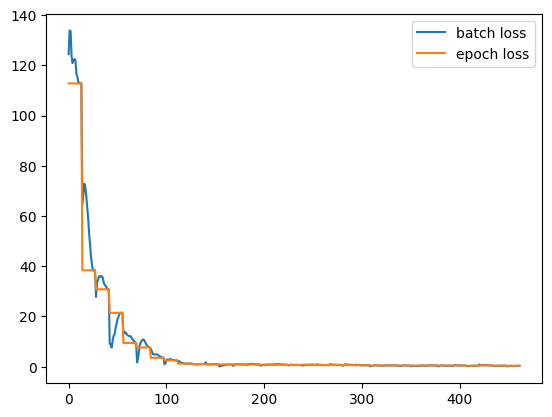

In [ ]:
# stretching epoch loss values to better fit the plot
# we have fewer epoch compared to batches
streched_epoch_loss = [[x] * 14 for x in history.history["loss"]]
flattened_epoch_loss = [a for b in streched_epoch_loss for a in b]

plt.plot(lossLogger.batch_loss, label= "batch loss")
plt.plot(flattened_epoch_loss, label = "epoch loss")
plt.legend();